In [1]:
import sys
sys.path.append('../')
import numpy as np
import os

from models.granger_pca import GrangerPCA
from models.teleconnection_models import RegressionAnalysis, CompositeAnalysis, CanonicalCorrelationAnalysis, SpatialAveraging, PrincipalComponents

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV

from src.granger_causality_test import test_granger_causality
from matplotlib import pyplot as plt
import seaborn as sns

import pandas as pd

In [2]:
# Ensure results directory exists
os.makedirs("../results/synth/", exist_ok=True)

# Set random seed
np.random.seed(2025)

# Parameters
N = 10000
m = 5            # total W dimension (must be multiple of 5)
d = 20             # observed X dimension
assert m % 5 == 0, "m must be divisible by 5"

# Generate base signals
t = np.arange(1, N+1)
X = np.random.normal(0, 1, (N, 1)) + np.sin(0.2 * t)[:, None] + np.cos(0.1 * t)[:, None]
Z1 = np.random.normal(0, 1, (N, 1)) + np.cos(0.4 * t)[:, None]
Z2 = np.random.normal(0, 1, (N, 1)) + np.cos(0.05 * t)[:, None]

block = m // 5     # block size
# Block indices
A = slice(0, block)
B = slice(block, 2 * block)
C = slice(2 * block, 3 * block)
D = slice(3 * block, 4 * block)
E = slice(4 * block, 5 * block)

# Initialize W
W = np.random.randn(N, m)

# Strength of causal link 
u = 0.2 

# Generate W according to VAR-like dependencies
for i in range(3, N):  # start from index 3 because of lag terms
    W[i, A] += (0.2 * W[i-2, A] + u*0.4 * X[i-1, 0] + u*0.3 * X[i-2, 0] +
                u*0.2 * X[i-3, 0] + 0.2 * Z1[i-1, 0] + 0.2 * Z1[i-2, 0])
    
    W[i, B] += 0.4 * W[i-1, B] + 0.5 * Z1[i-1, 0]
    
    W[i, C] += 0.1 * W[i-2, C] + 0.8 * Z1[i-2, 0] + 0.8 * W[i-1, A] + 0.4 * W[i-2, A]
    
    W[i, D] += 0.1 * W[i-2, D] - 0.7 * Z2[i-3, 0] + 0.8 * W[i-2, C]
    
    W[i, E] += 0.1 * W[i-1, E] + 0.8 * Z1[i-2, 0] + 0.6 * Z2[i-1, 0] + 0.2 * Z2[i-2, 0]

# Generate high-dimensional X
AA = np.random.randn(m, d)
Y = W #@ AA  # Matrix multiplication

# Save to CSV
np.savetxt("results/synth/X.csv", X, delimiter=",")
np.savetxt("results/synth/Y.csv", Y, delimiter=",")

FileNotFoundError: [Errno 2] No such file or directory: 'results/synth/X.csv'

In [ ]:
n = len(Y)
train_size = int(n * 0.8)

Y_train = Y[:train_size, :]
Y_test  = Y[train_size:, :]

X_train = X[:train_size, :]
X_test  = X[train_size:, :]

W_0_train = W[:train_size, 0]
W_0_test = W[train_size:, 0]

In [ ]:
X_train.shape, Y_train.shape

((8000, 1), (8000, 5))

In [ ]:
alphas = np.logspace(-3, 8, 100)
gpca = GrangerPCA(maxlag=3, maxlags=range(1, 5), method='diff_ratio', lag_criterion='BIC')#, mu=0.5, model_res=RidgeCV(alphas=alphas), model_full=RidgeCV(alphas=alphas), alpha=1e-7)
gpca.fit(X_train, Y_train, Z=None, plot_lag_analysis=True, verbose=True)

conflicted sign: lag 1:positive, lag 2:negative, lag 3:negative
       eigs
0  0.037043
1  0.002224
2  0.000200


In [ ]:
cp_test_gpca = gpca.transform(Y_test)
results_gpca = test_granger_causality(X_test, cp_test_gpca[:, 0], maxlag=gpca.maxlag)

In [ ]:
ca = CompositeAnalysis(maxlag=gpca.maxlag)
ca.fit(X_train, Y_train)
cp_test_ca = ca.transform(Y_test, type='PosNeg')

ra = RegressionAnalysis(maxlag=gpca.maxlag)
ra.fit(X_train, Y_train)
cp_test_ra = ra.transform(Y_test)

cca = CanonicalCorrelationAnalysis(maxlag=gpca.maxlag, n_components=1)
cca.fit(X_train, Y_train)
cp_test_cca = cca.transform(Y_test)

sa = SpatialAveraging()
sa.fit(X_train, Y_train)
cp_test_sa = sa.transform(Y_test)

pc = PrincipalComponents()
pc.fit(X_train, Y_train)
cp_test_pc = pc.transform(Y_test)

In [ ]:
results_gpca = test_granger_causality(X_test[:, None], cp_test_gpca[:, 0], maxlag=[gpca.maxlag])
results_ra = test_granger_causality(X_test[:, None], cp_test_ra, maxlag=[gpca.maxlag])
results_ca = test_granger_causality(X_test[:, None], cp_test_ca, maxlag=[gpca.maxlag])
results_cca = test_granger_causality(X_test[:, None], cp_test_cca, maxlag=[gpca.maxlag])
results_sa = test_granger_causality(X_test[:, None], cp_test_sa, maxlag=[gpca.maxlag])
results_pc = test_granger_causality(X_test[:, None], cp_test_pc, maxlag=[gpca.maxlag])

In [ ]:
# Combine your results (with method names as keys)
combined = pd.concat(
    [
        results_gpca[results_gpca['lag'] == gpca.maxlag],
        results_cca[results_cca['lag'] == gpca.maxlag],
        results_ca[results_ca['lag'] == gpca.maxlag],
        results_ra[results_ra['lag'] == gpca.maxlag],
        results_sa[results_sa['lag'] == gpca.maxlag],
        results_pc[results_pc['lag'] == gpca.maxlag]
    ],
    keys=['GPCA', 'CCA', 'Composites', 'Regression', 'Spatial Average', 'PCA']
).reset_index(level=0).rename(columns={'level_0': 'Method'})

# Export to LaTeX using scientific notation
latex_table = combined[['F_statistic', 'p_value']].to_latex(
    index=True,
    caption=f"Comparison of Results by Method at lag = {gpca.maxlag}",
    label="tab:results_by_method",
    float_format=lambda x: f"{x:.3e}",  # scientific notation with 3 decimals
    escape=True
)

# Save to file
with open("tables/synthetic_pvalues_large_high.tex", "w") as f:
    f.write(latex_table)


In [ ]:
combined

,Method,lag,Y_column,F_statistic,df1,df2,p_value,F_critical,alpha_used,interpretation
0,GPCA,3,1,17.959476,3,1991,1.681908e-11,2.609372,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3)
0,CCA,3,1,12.497384,3,1991,4.271223e-08,2.609372,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3)
0,Composites,3,1,14.443042,3,1991,2.615919e-09,2.609372,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3)
0,Regression,3,1,13.263183,3,1991,1.423060e-08,2.609372,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3)
0,Spatial Average,3,1,4.494072,3,1991,3.775298e-03,2.609372,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3)
0,PCA,3,1,4.706519,3,1991,2.807115e-03,2.609372,0.05,Reject H₀ (α=0.05000): X Granger-causes Y (lag=3)


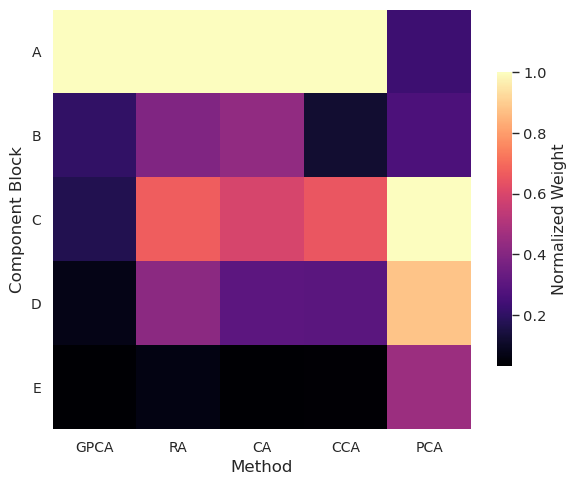

In [ ]:
# Compute weights (same as your setup)
weights_gpca = np.abs(gpca.vects_)[:, 0, None] / np.abs(gpca.vects_)[:, 0, None].max()
weights_ra = np.abs(ra.lr.coef_) / np.abs(ra.lr.coef_.max())
weights_ca = np.abs(ca.composites['PosNeg'].to_numpy())[:, None] / np.abs(ca.composites['PosNeg'].to_numpy()[:, None].max())
weights_cca = np.abs(cca.cca.y_loadings_) / np.abs(cca.cca.y_loadings_.max())
weights_pc = np.abs(pc.pca.components_.T) / np.abs(pc.pca.components_[0, :].max())

# Combine into DataFrame
df_weights = pd.DataFrame(
    np.array([weights_gpca, weights_ra, weights_ca, weights_cca, weights_pc])[:, :, 0].T,
    columns=['GPCA', 'RA', 'CA', 'CCA', 'PCA']
)

# --- Styling setup ---
sns.set_theme(context='paper', style='white', font='sans-serif', font_scale=1.2)
plt.figure(figsize=(6, 5))  # small, tight figure

# --- Heatmap ---
ax = sns.heatmap(
    df_weights,
    cmap='magma',
    cbar_kws={'shrink': 0.7, 'label': 'Normalized Weight'},
    linewidths=0.0,
    linecolor='white',
    square=False,        # <- allow rectangular cells
    fmt='.2f',
    annot_kws={"size": 9, "color": "black"},
    yticklabels=False
)

# --- Custom Y labels: 5 equally spaced blocks ---
labels = ["A", "B", "C", "D", "E"]
n_blocks = len(labels)
n_rows = df_weights.shape[0]

block_size = n_rows / n_blocks
tick_positions = [block_size*(i + 0.5) for i in range(n_blocks)]

ax.set_yticks(tick_positions)
ax.set_yticklabels(labels, rotation=0, fontsize=12)

# --- Labels & layout ---
ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('Component Block', fontsize=12)

# --- Polish ticks ---
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_aspect("auto")  # allow vertical squeezing

plt.tight_layout()

# --- Save ---
plt.savefig('figures/weights_toy_model.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


# Running experiments for various settings testing type I and II errors

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

from functions_synthetic_experiements import run_experiment, generate_m_values


# ============================================================
# PARAMETERS
# ============================================================

alpha = 0.05
B = 5              # Monte Carlo repetitions
n_grid = 10        # 10x10 grid
N_min, N_max = 100, 1000
m_min, m_max = 5, 1000
u = 0.2 # 0 for type I error
# ============================================================
# 1. BUILD 10x10 GRID
# ============================================================

N_values = np.unique(
    np.logspace(np.log10(N_min), np.log10(N_max), n_grid).astype(int)
).astype(int)

m_values = generate_m_values(n_points=n_grid, m_min=m_min, m_max=m_max)

print("N grid:", N_values)
print("m grid:", m_values)


# ============================================================
# 2. RUN MONTE CARLO EXPERIMENTS
# ============================================================

results_storage = []

for N in tqdm(N_values):
    for m in m_values:

        for b in range(B):

            results_df, _ = run_experiment(
                N=N,
                m=m,
                d=20,
                u=u      # change to 0 for size study
            )

            for _, row in results_df.iterrows():
                results_storage.append({
                    "N": N,
                    "m": m,
                    "Method": row["Method"],
                    "reject": row["p_value"] <= alpha,
                    "p_value": row["p_value"]
                })

grid_df = pd.DataFrame(results_storage)


# ============================================================
# 3. COMPUTE REJECTION RATES
# ============================================================

rejection_df = (
    grid_df
    .groupby(["N", "m", "Method"])["reject"]
    .mean()
    .reset_index()
    .rename(columns={"reject": "rejection_rate"})
)

os.makedirs("figures/grid_experiments", exist_ok=True)
rejection_df.to_csv(
    "figures/grid_experiments/rejection_rates_10x10_B20.csv",
    index=False
)

print("Saved rejection rates.")

N grid: [ 100  129  166  215  278  359  464  599  774 1000]
m grid: [   5   10   15   30   55   95  170  310  555 1000]


 90%|█████████ | 9/10 [1:25:36<13:20, 800.72s/it]

In [ ]:
# ============================================================
# 4. PLOT REJECTION RATE HEATMAPS (Publication Quality)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Global style settings (large, publication-ready typography)
# ------------------------------------------------------------
plt.rcParams.update({
    "text.usetex": False,              # Set True if LaTeX installed
    "font.family": "serif",
    "font.size": 24,                   # Base font size
    "axes.titlesize": 26,
    "axes.labelsize": 26,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 24,
    "figure.titlesize": 26,
    "axes.linewidth": 1.5
})

methods = sorted(rejection_df["Method"].unique())

fig, axes = plt.subplots(
    1,
    len(methods),
    figsize=(6.5 * len(methods), 7.5),
    sharex=True,
    sharey=True
)

if len(methods) == 1:
    axes = [axes]

# Use a perceptually uniform colormap
cmap = plt.get_cmap("viridis")

for ax, method in zip(axes, methods):

    df_m = rejection_df[rejection_df["Method"] == method]

    heatmap_data = (
        df_m.pivot(index="m", columns="N", values="rejection_rate")
        .sort_index(ascending=True)
    )

    im = ax.imshow(
        heatmap_data.values,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=0,
        vmax=1
    )

    # Ticks
    ax.set_xticks(np.arange(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns, rotation=45)

    ax.set_yticks(np.arange(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)

    # Labels and titles
    ax.set_title(method, pad=15, fontweight="bold")
    ax.set_xlabel(r"Sample size $N$", labelpad=10)
    ax.set_ylabel(r"Dimensionality $d$", labelpad=10)

    # Thicker tick marks
    ax.tick_params(axis='both', which='major', width=1.5, length=6)

    # Optional: annotate values inside cells (uncomment if desired)
    """
    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            value = heatmap_data.values[i, j]
            ax.text(
                j, i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if value > 0.5 else "black",
                fontsize=14
            )
    """

# ------------------------------------------------------------
# Shared colorbar (clean placement below panels)
# ------------------------------------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.08,
    pad=-0.3
)

cbar.set_label(r"Rejection rate ($\alpha = {}$)".format(alpha), fontsize=24)
cbar.ax.tick_params(labelsize=26, width=1.5, length=6)

# Improve spacing
plt.tight_layout()

# Save as high-resolution PNG
plt.savefig(
    "figures/grid_experiments/rejection_rate_heatmaps_10x10_B20_null.png",
    dpi=400,
    bbox_inches="tight"
)

# Also save vector version (recommended for journals)
plt.savefig(
    "figures/grid_experiments/rejection_rate_heatmaps_10x10_B20_null.pdf",
    bbox_inches="tight"
)

plt.show()

NameError: name 'rejection_df' is not defined